# Data General

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# importar todas las librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [3]:
# Leer
df = pd.read_csv('/content/drive/MyDrive/Proyecto Democracia/3 Binario (RJ, B, RY).csv') # La BD con los paises

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246351 entries, 0 to 246350
Data columns (total 26 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   A_1       246351 non-null  float64
 1   A_2       246351 non-null  float64
 2   A_3       183250 non-null  float64
 3   C_4       246351 non-null  float64
 4   D_5       246351 non-null  float64
 5   D_6       246351 non-null  float64
 6   D_7       246351 non-null  float64
 7   D_8       246351 non-null  float64
 8   D_9       246351 non-null  float64
 9   H_10      246351 non-null  float64
 10  H_11      246351 non-null  float64
 11  H_12      246351 non-null  float64
 12  H_13      246351 non-null  float64
 13  H_14      246351 non-null  float64
 14  H_15      246351 non-null  float64
 15  S_16      246351 non-null  float64
 16  S_17      246351 non-null  float64
 17  S_18      246351 non-null  float64
 18  S_19      246351 non-null  float64
 19  S_20      246351 non-null  float64
 20  S_21

In [5]:
df.shape

(246351, 26)

# Extracción de Ecuador

In [6]:
df_filtered = df[df['X_23'] == 218]
display(df_filtered.head())

,A_1,A_2,A_3,C_4,D_5,D_6,D_7,D_8,D_9,H_10,...,S_17,S_18,S_19,S_20,S_21,S_22,X_23,X_24,X_25,ETIQUETA
6410,2.0,8.0,96.0,1.0,3.0,0.0,0.0,0.0,0.0,3.0,...,60.0,1.0,4.0,1.0,5.0,1.0,218.0,1996.0,NaN,1.0
6411,1.0,10.0,218019.0,1.0,3.0,0.0,0.0,1.0,0.0,3.0,...,31.0,1.0,6.0,6.0,3.0,1.0,218.0,1996.0,NaN,1.0
6412,1.0,7.0,218005.0,1.0,3.0,0.0,0.0,1.0,1.0,3.0,...,19.0,1.0,6.0,3.0,4.0,1.0,218.0,1996.0,NaN,1.0
6413,1.0,5.0,96.0,1.0,3.0,0.0,1.0,1.0,1.0,3.0,...,44.0,1.0,13.0,1.0,2.0,2.0,218.0,1996.0,NaN,0.0
6414,1.0,4.0,218005.0,1.0,3.0,0.0,1.0,1.0,0.0,3.0,...,21.0,1.0,6.0,1.0,4.0,1.0,218.0,1996.0,NaN,0.0


Número de filas y columnas después de la extracción

In [7]:
df_filtered.shape

(16607, 26)

La variable X_24 corresponde al año. Tener en cuenta la siguiente información:

Codification Years:

2011 -> 16

2013 -> 17

2015 -> 18

2023 -> 23

Años Faltantes:  1995, 1999, 2012, 2014, 2016, 2019, 2021, 2022

In [8]:
unique_x24_count = df_filtered['X_24'].nunique()
print(f"Number of unique values in X_24: {unique_x24_count}")

Number of unique values in X_24: 21


# Extraer solo desde 1998 a 2023 para ECU (df_filtered)

In [9]:
df_filtered = df_filtered[~df_filtered['X_24'].isin([1996.0, 1997.0])]


In [10]:
df_filtered.shape

(14943, 26)

In [11]:
unique_x24_count = df_filtered['X_24'].nunique()
print(f"Number of unique values in X_24: {unique_x24_count}")

Number of unique values in X_24: 19


# Graficos Variables ECU

Gráficos de distribución para cada variable

### A_1: Support for democracy

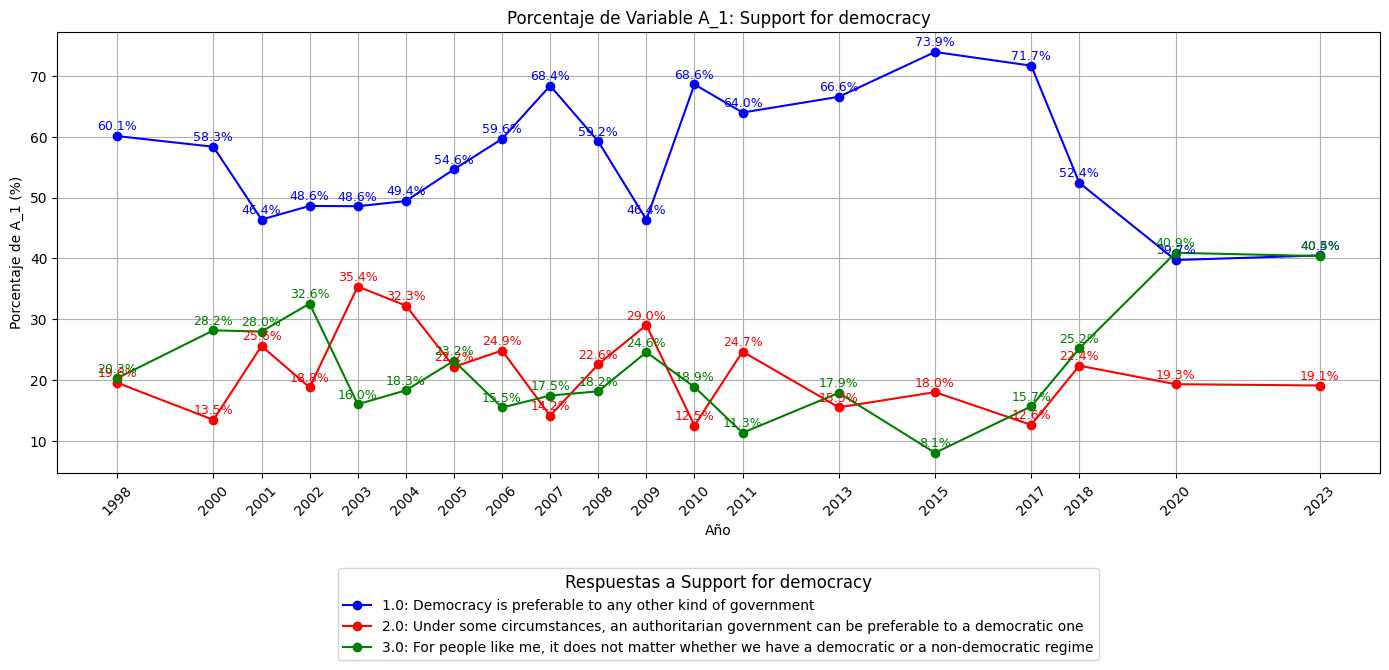

In [12]:
# Reconstruct df_for_plot with X_24 for plotting from the original df
df_for_plot = df[df['X_23'] == 218].copy()
df_for_plot = df_for_plot[~df_for_plot['X_24'].isin([1996.0, 1997.0])].copy()

# Map coded years to actual years for plotting clarity
year_mapping = {
    16.0: 2011.0,
    17.0: 2013.0,
    18.0: 2015.0,
    23.0: 2023.0
}
df_for_plot['X_24'] = df_for_plot['X_24'].replace(year_mapping)

# Group by year and A_1, then calculate percentages
df_plot_data_A1 = df_for_plot.groupby(['X_24', 'A_1']).size().unstack(fill_value=0)
df_plot_data_A1_percent = df_plot_data_A1.div(df_plot_data_A1.sum(axis=1), axis=0) * 100

# Sort by year to ensure correct temporal order in the plot
df_plot_data_A1_percent = df_plot_data_A1_percent.sort_index()

# Define the full descriptions for A_1 values
a1_descriptions = {
    1: 'Democracy is preferable to any other kind of government',
    2: 'Under some circumstances, an authoritarian government can be preferable to a democratic one',
    3: 'For people like me, it does not matter whether we have a democratic or a non-democratic regime'
}

# Plotting
plt.figure(figsize=(14, 7))

colors = ['blue', 'red', 'green', 'purple', 'orange'] # Define a list of colors for different A_1 values

for i, col in enumerate(df_plot_data_A1_percent.columns):
    # Get the full description for the current A_1 value
    legend_label = a1_descriptions.get(col, f'A_1 {col} (%)') # Fallback if description not found
    plt.plot(df_plot_data_A1_percent.index, df_plot_data_A1_percent[col], marker='o', label=f'{col}: {legend_label}', color=colors[i % len(colors)])
    for x, y in zip(df_plot_data_A1_percent.index, df_plot_data_A1_percent[col]):
        plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=9, color=colors[i % len(colors)])

plt.title('Porcentaje de Variable A_1: Support for democracy')
plt.xlabel('Año')
plt.ylabel('Porcentaje de A_1 (%)')
plt.xticks(df_plot_data_A1_percent.index.astype(int), rotation=45) # Show all years as integers
plt.grid(True)
plt.legend(title='Respuestas a Support for democracy', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=1, fontsize='medium', title_fontsize='large') # Move legend below the plot and arrange vertically, with custom font sizes
plt.tight_layout()
plt.show()

### C_4: Trabajo

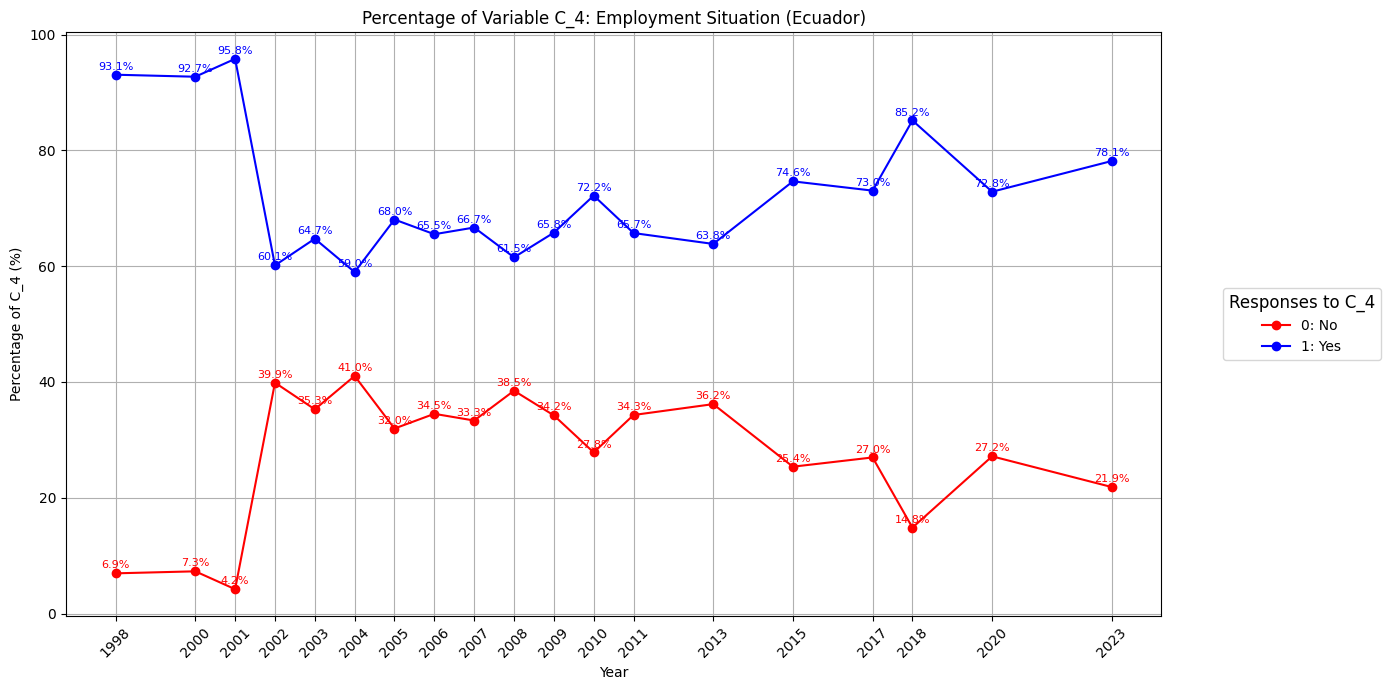

In [13]:
# Group by year and C_4, then calculate percentages
df_plot_data_C4 = df_for_plot.groupby(['X_24', 'C_4']).size().unstack(fill_value=0)
df_plot_data_C4_percent = df_plot_data_C4.div(df_plot_data_C4.sum(axis=1), axis=0) * 100

# Sort by year to ensure correct temporal order in the plot
df_plot_data_C4_percent = df_plot_data_C4_percent.sort_index()

# Define descriptions for C_4 values (assuming 0 for No, 1 for Yes based on previous plots)
c4_descriptions = {
    0.0: 'No',
    1.0: 'Yes'
}

# Plotting
plt.figure(figsize=(14, 7))

# Use distinct colors for C_4 categories
c_4_colors = {0.0: 'red', 1.0: 'blue'}

for col in df_plot_data_C4_percent.columns:
    legend_label = c4_descriptions.get(col, f'C_4 {int(col)}')
    plt.plot(df_plot_data_C4_percent.index, df_plot_data_C4_percent[col],
             marker='o', label=f'{int(col)}: {legend_label}', color=c_4_colors.get(col))

    # Annotate points with percentage values
    for x, y in zip(df_plot_data_C4_percent.index, df_plot_data_C4_percent[col]):
        if y > 0: # Only annotate if percentage is greater than 0
            plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=8, color=c_4_colors.get(col))

plt.title('Percentage of Variable C_4: Employment Situation (Ecuador)')
plt.xlabel('Year')
plt.ylabel('Percentage of C_4 (%)')
plt.xticks(df_plot_data_C4_percent.index.astype(int), rotation=45)
plt.grid(True)
plt.legend(title='Responses to C_4', bbox_to_anchor=(1.05, 0.5), loc='center left', ncol=1,
           fontsize='medium', title_fontsize='large') # Place legend on the right
plt.tight_layout() # Adjust layout to prevent labels/legend from overlapping
plt.show()

# Gráfico Etiqueta: Satisfacción con la democracia ECU

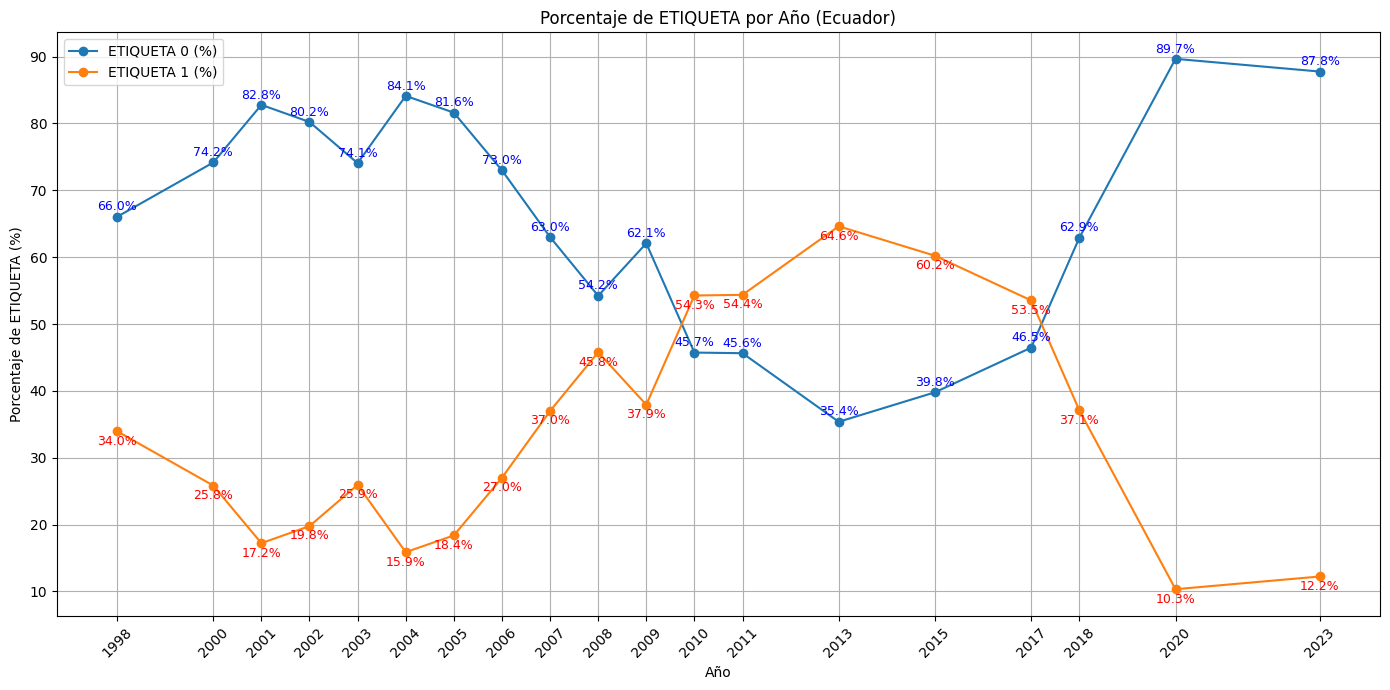

In [14]:
# Reconstruct df_filtered with X_24 for plotting from the original df
df_for_plot = df[df['X_23'] == 218].copy()
df_for_plot = df_for_plot[~df_for_plot['X_24'].isin([1996.0, 1997.0])].copy()

# Map coded years to actual years for plotting clarity
year_mapping = {
    16.0: 2011.0,
    17.0: 2013.0,
    18.0: 2015.0,
    23.0: 2023.0
}
df_for_plot['X_24'] = df_for_plot['X_24'].replace(year_mapping)

# Group by year and ETIQUETA, then calculate percentages
df_plot_data = df_for_plot.groupby(['X_24', 'ETIQUETA']).size().unstack(fill_value=0)
df_plot_data_percent = df_plot_data.div(df_plot_data.sum(axis=1), axis=0) * 100

# Sort by year to ensure correct temporal order in the plot
df_plot_data_percent = df_plot_data_percent.sort_index()

# Plotting
plt.figure(figsize=(14, 7)) # Increased figure size for better readability of annotations

if 0.0 in df_plot_data_percent.columns:
    plt.plot(df_plot_data_percent.index, df_plot_data_percent[0.0], marker='o', label='ETIQUETA 0 (%)')
    for x, y in zip(df_plot_data_percent.index, df_plot_data_percent[0.0]):
        plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=9, color='blue') # Annotate points for ETIQUETA 0

if 1.0 in df_plot_data_percent.columns:
    plt.plot(df_plot_data_percent.index, df_plot_data_percent[1.0], marker='o', label='ETIQUETA 1 (%)')
    for x, y in zip(df_plot_data_percent.index, df_plot_data_percent[1.0]):
        plt.text(x, y - 0.5, f'{y:.1f}%', ha='center', va='top', fontsize=9, color='red') # Annotate points for ETIQUETA 1

plt.title('Porcentaje de ETIQUETA por Año (Ecuador)')
plt.xlabel('Año')
plt.ylabel('Porcentaje de ETIQUETA (%)')
plt.xticks(df_plot_data_percent.index.astype(int), rotation=45) # Show all years as integers
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Por Periodos

Primer Periodo: 1998 - 2006 (verificar años) Pre-Correismo

Segundo Periodo: 2007 - 2017 (verificar años) Correísmo

Tercer Periodo: 2018 - 2023 (verificar años) Postcorreismo (años faltantes)

Un año representativo por periodo: 2000, 2013, 2023.

## Preprocesamiento

In [15]:
df_filtered.shape

(14943, 26)

Eliminar las columnas:
A_3: Partidos Políticos, X_23: Country, X_24: Year y X_25: Region

In [16]:
df_period= df_filtered.drop(columns=['A_3', 'X_23', 'X_25'])
# A_3 partidos políticos
# X_23 País: valor único
# X_24 Año se convierte en un periodo
# X_25 Region/Geographical area

In [17]:
cat_cols = ['A_1', 'A_2', 'S_20', 'S_22']
df = pd.get_dummies(df_period, columns=cat_cols, drop_first=True).astype(int)
# A_1 Support for democracy
# A_2 Self positioning on Left-Right Scale
# S_20 Employment Situation
# S_22 Religion

In [18]:
df.shape

(14943, 52)

## Primer Periodo (1998-2006)

In [19]:
years_first_period = [1998, 2000, 2001, 2002, 2003, 2004, 2005, 2006]
df_first_period = df[df['X_24'].isin(years_first_period)]
df_first_period = df_first_period.drop('X_24', axis=1)

print("Shape of df_first_period:", df_first_period.shape)

Shape of df_first_period: (5985, 51)


### Decision Tree

Data Splitting

In [20]:
# Construction of a function that performs full partitioning
def train_test_splitnew(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.2, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, test_set)

In [21]:
# Asume que 'ETIQUETA' es la columna target
train_set_encoded, test_set_encoded = train_test_splitnew(df_first_period, stratify='ETIQUETA')

# Separar X e y para cada subconjunto
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

Definir modelo e hiperparámetros

In [22]:
# Modelo base
dt_firstencoded = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_firstencoded = GridSearchCV(
    estimator=dt_firstencoded,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_firstencoded.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_dt_model_firstencoded = grid_search_dt_firstencoded.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [23]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_firstencoded.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: None
max_features: sqrt
min_samples_split: 2


Resultados

In [24]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_firstencoded.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       918
           1       0.33      0.32      0.33       279

    accuracy                           0.69      1197
   macro avg       0.56      0.56      0.56      1197
weighted avg       0.69      0.69      0.69      1197



In [25]:
best_dt_model_firstencoded.feature_importances_

array([2.23828953e-02, 6.36076419e-02, 1.92312734e-02, 1.64700471e-02,
       1.44991626e-02, 2.29986645e-02, 4.11205604e-02, 3.68770172e-02,
       5.78786563e-02, 6.03230956e-02, 5.08298493e-02, 2.52642332e-02,
       2.57381425e-02, 1.30402807e-01, 2.49486345e-02, 8.22401770e-02,
       5.43982421e-02, 5.27917657e-03, 1.23607588e-02, 7.71679916e-03,
       1.19144671e-02, 9.73314732e-03, 1.31008959e-02, 2.79959498e-02,
       1.39820046e-02, 9.09518153e-03, 1.06796901e-02, 6.96284645e-03,
       1.82482249e-02, 1.14154944e-02, 1.74770801e-02, 1.11992893e-02,
       5.97786873e-03, 1.62013153e-02, 8.12398321e-03, 1.43930548e-02,
       1.83122278e-03, 0.00000000e+00, 2.09322845e-04, 9.62400548e-04,
       3.67864722e-03, 7.22500097e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.68055784e-03, 0.00000000e+00, 3.94869512e-05,
       7.45287151e-03, 1.35466219e-03])

In [27]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_dt_model_firstencoded.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.130403
S_19,0.082240
D_5,0.063608
H_13,0.060323
H_12,0.057879


### Random Forest

In [28]:
# Modelo base
rf_firstencoded = RandomForestClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Búsqueda de hiperparámetros usando 5-fold CV sobre el TRAIN
grid_search_rf_firstencoded = GridSearchCV(
    estimator=rf_firstencoded,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar con TRAIN
grid_search_rf_firstencoded.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_rf_model_firstencoded = grid_search_rf_firstencoded.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [29]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_rf_firstencoded.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
max_depth: None
max_features: sqrt
min_samples_split: 2
n_estimators: 100


In [30]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_rf_model_firstencoded.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       918
           1       0.77      0.13      0.22       279

    accuracy                           0.79      1197
   macro avg       0.78      0.56      0.55      1197
weighted avg       0.78      0.79      0.72      1197



In [31]:
best_rf_model_firstencoded.feature_importances_

array([1.91870839e-02, 5.73643433e-02, 1.85285078e-02, 2.05398683e-02,
       2.00090120e-02, 2.27995722e-02, 3.42081710e-02, 3.91574603e-02,
       5.09684578e-02, 4.66414050e-02, 5.18220821e-02, 3.53618792e-02,
       2.51981586e-02, 1.31090443e-01, 2.29490260e-02, 8.58163036e-02,
       5.05122113e-02, 2.20549025e-02, 1.93328836e-02, 6.83578207e-03,
       9.13531016e-03, 1.30084798e-02, 1.11695467e-02, 2.33957358e-02,
       1.47605479e-02, 1.13579661e-02, 1.29549845e-02, 1.00026660e-02,
       1.54999119e-02, 1.42861807e-02, 1.49664756e-02, 9.52555349e-03,
       5.46584164e-03, 1.67041968e-02, 9.64074773e-03, 9.86177090e-03,
       9.16021002e-04, 0.00000000e+00, 1.29521223e-03, 1.26874370e-03,
       2.82455202e-03, 7.91493006e-04, 3.42322860e-06, 1.39421232e-04,
       2.68957191e-05, 1.32104345e-03, 2.76497105e-04, 6.80429171e-04,
       6.31894834e-03, 2.02384997e-03])

In [32]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_rf_model_firstencoded.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.131090
S_19,0.085816
D_5,0.057364
H_14,0.051822
H_12,0.050968


### Logistic Regression

In [33]:
# Modelo base
lr_periodo1 = LogisticRegression(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Búsqueda de hiperparámetros
grid_search_lr_periodo1 = GridSearchCV(
    estimator=lr_periodo1,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search_lr_periodo1.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_lr_model_periodo1 = grid_search_lr_periodo1.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [34]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_lr_periodo1.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
C: 10
penalty: l2
solver: liblinear


In [35]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_lr_model_periodo1.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       918
           1       0.41      0.03      0.05       279

    accuracy                           0.76      1197
   macro avg       0.59      0.51      0.46      1197
weighted avg       0.69      0.76      0.67      1197



## Segundo Periodo (2007-2017)

In [36]:
years_second_period = [2007, 2008, 2009, 2010, 16, 17, 18, 2017] # 16 es 2011, 17 es 2013 y 15 es2018
df_second_period = df[df['X_24'].isin(years_second_period)]
df_second_period = df_second_period.drop('X_24', axis=1)

print("Shape of df_second_period:", df_second_period.shape)
#display(df_second_period.head())

Shape of df_second_period: (6512, 51)


### Decision Tree

Data Splitting

In [37]:
# Asume que 'ETIQUETA' es la columna target
train_set_encoded, test_set_encoded = train_test_splitnew(df_second_period, stratify='ETIQUETA')

# Separar X e y para cada subconjunto
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

Definir modelo y encontrar hiperparámetros

In [38]:
# Modelo base
dt_secondencoded = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_secondencoded = GridSearchCV(
    estimator=dt_secondencoded,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_secondencoded.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_dt_model_secondencoded = grid_search_dt_secondencoded.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [39]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_secondencoded.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: 5
max_features: log2
min_samples_split: 10


In [40]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_secondencoded.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.62      0.38      0.47       633
           1       0.57      0.78      0.66       670

    accuracy                           0.59      1303
   macro avg       0.60      0.58      0.57      1303
weighted avg       0.60      0.59      0.57      1303



In [41]:
best_dt_model_secondencoded.feature_importances_

array([0.        , 0.        , 0.00316916, 0.        , 0.        ,
       0.0492559 , 0.34626051, 0.00412886, 0.08404293, 0.0237346 ,
       0.01587813, 0.        , 0.        , 0.00586219, 0.        ,
       0.02546505, 0.02108937, 0.        , 0.35418899, 0.00370704,
       0.        , 0.        , 0.        , 0.00205065, 0.02887921,
       0.0061721 , 0.        , 0.00384427, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00902797, 0.        , 0.        , 0.        , 0.        ,
       0.01123176, 0.        , 0.00201129, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [42]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_dt_model_secondencoded.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
A_1_3.0,0.354189
H_10,0.346261
H_12,0.084043
D_9,0.049256
A_2_6.0,0.028879


### Random Forest

In [43]:
# Modelo base
rf_secondencoded = RandomForestClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Búsqueda de hiperparámetros usando 5-fold CV sobre el TRAIN
grid_search_rf_secondencoded = GridSearchCV(
    estimator=rf_secondencoded,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar con TRAIN
grid_search_rf_secondencoded.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_rf_model_secondencoded = grid_search_rf_secondencoded.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [44]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_rf_secondencoded.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
max_depth: None
max_features: sqrt
min_samples_split: 5
n_estimators: 50


In [45]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_rf_model_secondencoded.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       633
           1       0.68      0.64      0.66       670

    accuracy                           0.66      1303
   macro avg       0.66      0.66      0.66      1303
weighted avg       0.66      0.66      0.66      1303



In [46]:
best_rf_model_secondencoded.feature_importances_

array([1.57330280e-02, 9.81144268e-02, 2.08063362e-02, 1.63605079e-02,
       1.69704903e-02, 2.06783879e-02, 7.15067652e-02, 5.15843212e-02,
       4.23442734e-02, 4.38306182e-02, 4.70964660e-02, 4.20333690e-02,
       1.91030916e-02, 1.11347477e-01, 1.79076236e-02, 6.94337660e-02,
       4.09025307e-02, 1.70830425e-02, 3.08106698e-02, 8.94014696e-03,
       8.85005510e-03, 1.01442455e-02, 1.29115031e-02, 1.87531454e-02,
       1.30622895e-02, 1.36336049e-02, 9.90598800e-03, 7.42048471e-03,
       7.01452105e-03, 1.08104365e-02, 1.56924689e-02, 5.87397854e-03,
       4.34386385e-03, 1.38425300e-02, 9.85976976e-03, 1.48132640e-02,
       9.79451509e-04, 2.07386636e-04, 1.04822463e-03, 1.75142516e-03,
       3.99197128e-03, 1.27864830e-03, 7.11647659e-04, 1.16065266e-04,
       4.95573695e-05, 6.30288571e-04, 6.58923973e-05, 5.56177677e-04,
       8.87065004e-03, 2.23125969e-04])

In [47]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_rf_model_secondencoded.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.111347
D_5,0.098114
H_10,0.071507
S_19,0.069434
H_11,0.051584


### Logistic Regresion

In [48]:
# Modelo base
lr_periodo2 = LogisticRegression(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Búsqueda de hiperparámetros
grid_search_lr_periodo2 = GridSearchCV(
    estimator=lr_periodo2,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search_lr_periodo2.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_lr_model_periodo2 = grid_search_lr_periodo2.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [49]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_lr_periodo2.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
C: 1
penalty: l2
solver: liblinear


In [50]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_lr_model_periodo2.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.67      0.66      0.66       633
           1       0.68      0.69      0.69       670

    accuracy                           0.67      1303
   macro avg       0.67      0.67      0.67      1303
weighted avg       0.67      0.67      0.67      1303



## Tercer Periodo (2018-2023)

In [51]:
years_third_period = [2018, 2020, 23]
df_third_period = df[df['X_24'].isin(years_third_period)]
df_third_period = df_third_period.drop('X_24', axis=1)

print("Shape of df_third_period:", df_third_period.shape)
#display(df_third_period.head())

Shape of df_third_period: (2446, 51)


### Decision Tree

In [52]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_third_period, stratify='ETIQUETA')
# Separar X e y para cada subconjunto
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [53]:
# Modelo base
dt_thirdencoded = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_thirdencoded = GridSearchCV(
    estimator=dt_thirdencoded,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_thirdencoded.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_dt_model_thirdencoded = grid_search_dt_thirdencoded.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [54]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_thirdencoded.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: None
max_features: None
min_samples_split: 2


In [55]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_thirdencoded.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       391
           1       0.33      0.30      0.32        99

    accuracy                           0.73       490
   macro avg       0.58      0.57      0.58       490
weighted avg       0.73      0.73      0.73       490



In [56]:
best_dt_model_thirdencoded.feature_importances_

array([0.00805211, 0.10864181, 0.01302008, 0.0130054 , 0.01763765,
       0.01361134, 0.03805145, 0.0351984 , 0.0529709 , 0.04387304,
       0.04409139, 0.06079555, 0.02595857, 0.15685099, 0.01107767,
       0.04691659, 0.04880051, 0.01032714, 0.02684363, 0.01151091,
       0.00849023, 0.02088497, 0.01305719, 0.02100701, 0.00803552,
       0.01187225, 0.00226007, 0.00892789, 0.00942451, 0.00536914,
       0.01927604, 0.01004539, 0.00748158, 0.01464395, 0.01364974,
       0.02143443, 0.        , 0.        , 0.00231832, 0.        ,
       0.        , 0.00326411, 0.        , 0.00318157, 0.        ,
       0.        , 0.        , 0.        , 0.00814095, 0.        ])

In [57]:
# Podemos extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_dt_model_thirdencoded.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.156851
D_5,0.108642
H_15,0.060796
H_12,0.052971
S_21,0.048801


### Random Forest

In [58]:
# Modelo base
rf_thirdencoded = RandomForestClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Búsqueda de hiperparámetros usando 5-fold CV sobre el TRAIN
grid_search_rf_thirdencoded = GridSearchCV(
    estimator=rf_thirdencoded,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar con TRAIN
grid_search_rf_thirdencoded.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_rf_model_thirdencoded = grid_search_rf_thirdencoded.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [59]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_rf_thirdencoded.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
max_depth: None
max_features: sqrt
min_samples_split: 5
n_estimators: 50


In [60]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_rf_model_thirdencoded.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       391
           1       0.62      0.15      0.24        99

    accuracy                           0.81       490
   macro avg       0.72      0.56      0.57       490
weighted avg       0.78      0.81      0.76       490



In [61]:
best_rf_model_thirdencoded.feature_importances_

array([1.44980282e-02, 1.07030001e-01, 1.51823189e-02, 1.50146802e-02,
       1.54736394e-02, 2.21559708e-02, 5.66311423e-02, 6.47819171e-02,
       3.82448193e-02, 4.66398207e-02, 4.49109983e-02, 5.52070724e-02,
       1.88582191e-02, 1.08447020e-01, 1.74734413e-02, 7.23463067e-02,
       3.84335220e-02, 1.59674800e-02, 2.33074569e-02, 7.42395180e-03,
       6.65647394e-03, 1.26597336e-02, 1.14238303e-02, 2.07120569e-02,
       1.04490907e-02, 1.21928774e-02, 9.06457579e-03, 7.89671857e-03,
       9.61526743e-03, 9.25325281e-03, 1.28367267e-02, 9.19286244e-03,
       7.36688308e-03, 1.22587434e-02, 1.25248499e-02, 1.41692238e-02,
       2.53243623e-04, 0.00000000e+00, 5.13975813e-03, 6.74647014e-04,
       2.02155846e-03, 3.32670643e-03, 3.99243848e-08, 7.77009722e-04,
       0.00000000e+00, 8.30399449e-05, 8.43772312e-05, 1.01227154e-04,
       1.12092605e-02, 2.81595014e-05])

In [62]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_rf_model_thirdencoded.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.108447
D_5,0.107030
S_19,0.072346
H_11,0.064782
H_10,0.056631


### Logistic Regresion

In [63]:
# Modelo base
lr_periodo3 = LogisticRegression(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Búsqueda de hiperparámetros
grid_search_lr_periodo3 = GridSearchCV(
    estimator=lr_periodo3,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search_lr_periodo3.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_lr_model_periodo3 = grid_search_lr_periodo3.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [64]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_lr_periodo3.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
C: 10
penalty: l2
solver: liblinear


In [65]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_lr_model_periodo3.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       391
           1       0.50      0.18      0.27        99

    accuracy                           0.80       490
   macro avg       0.66      0.57      0.57       490
weighted avg       0.76      0.80      0.76       490



# Año representativo

## 2000

In [66]:
df_2000 = df[df['X_24'] == 2000].copy()
df_2000 = df_2000.drop('X_24', axis=1)

print("Shape of df_2000:", df_2000.shape)

Shape of df_2000: (809, 51)


### Decision Tree

In [117]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_2000, stratify='ETIQUETA')
# Separar X e y para cada subconjunto
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [68]:
# Modelo base
dt_2000 = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_2000 = GridSearchCV(
    estimator=dt_2000,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_2000.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_dt_model_2000 = grid_search_dt_2000.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [69]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_2000.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: None
max_features: sqrt
min_samples_split: 2


In [70]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_2000.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       120
           1       0.66      0.79      0.72        42

    accuracy                           0.84       162
   macro avg       0.79      0.82      0.80       162
weighted avg       0.85      0.84      0.84       162



In [71]:
best_dt_model_2000.feature_importances_

array([0.00945311, 0.05825648, 0.00990188, 0.02479877, 0.04071338,
       0.03151602, 0.05728878, 0.0516205 , 0.03023366, 0.04589608,
       0.04405244, 0.0474712 , 0.04588864, 0.13950774, 0.02760454,
       0.08787049, 0.02167058, 0.01353951, 0.02573948, 0.0184031 ,
       0.        , 0.00350224, 0.0108176 , 0.02028444, 0.00754013,
       0.00542099, 0.00570243, 0.00054496, 0.00171963, 0.05584411,
       0.01275339, 0.00258374, 0.00238552, 0.01020101, 0.02280547,
       0.00141615, 0.        , 0.        , 0.00260165, 0.        ,
       0.00080184, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.0016483 , 0.        ])

In [72]:
# Podemos extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_dt_model_2000.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.139508
S_19,0.087870
D_5,0.058256
H_10,0.057289
S_20_2.0,0.055844


### Random Forest

In [73]:
# Modelo base
rf_2000 = RandomForestClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Búsqueda de hiperparámetros usando 5-fold CV sobre el TRAIN
grid_search_rf_2000 = GridSearchCV(
    estimator=rf_2000,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar con TRAIN
grid_search_rf_2000.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_rf_model_2000 = grid_search_rf_2000.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [74]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_rf_2000.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
max_depth: None
max_features: sqrt
min_samples_split: 2
n_estimators: 50


In [75]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_rf_model_2000.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       120
           1       0.97      0.67      0.79        42

    accuracy                           0.91       162
   macro avg       0.93      0.83      0.86       162
weighted avg       0.91      0.91      0.90       162



In [76]:
best_rf_model_2000.feature_importances_

array([1.68250599e-02, 5.65826668e-02, 2.06798037e-02, 1.47804507e-02,
       2.51131306e-02, 2.36127701e-02, 4.90021991e-02, 4.44899479e-02,
       4.47961842e-02, 4.24595725e-02, 4.84064774e-02, 3.38879706e-02,
       3.46480169e-02, 1.17156270e-01, 2.23939510e-02, 9.10362242e-02,
       4.87686730e-02, 1.56959871e-02, 2.85838720e-02, 5.66111326e-03,
       7.35768363e-03, 1.09040923e-02, 1.89392994e-02, 2.18182070e-02,
       1.19996149e-02, 9.45899327e-03, 7.94551799e-03, 3.29019511e-03,
       2.01571864e-02, 1.69950726e-02, 1.63094786e-02, 1.22116663e-02,
       2.86161013e-03, 1.81221226e-02, 1.30584546e-02, 8.80945436e-03,
       2.71377725e-03, 0.00000000e+00, 1.19618864e-03, 0.00000000e+00,
       5.40613976e-03, 9.99638347e-04, 0.00000000e+00, 1.84326472e-04,
       7.48594717e-05, 3.56418811e-04, 1.26134647e-04, 0.00000000e+00,
       4.12352576e-03, 0.00000000e+00])

In [77]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_rf_model_2000.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.117156
S_19,0.091036
D_5,0.056583
H_10,0.049002
S_21,0.048769


### Logistic Regresion

In [78]:
# Modelo base
lr_2000 = LogisticRegression(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Búsqueda de hiperparámetros
grid_search_lr_2000 = GridSearchCV(
    estimator=lr_2000,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search_lr_2000.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_lr_model_2000 = grid_search_lr_2000.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [79]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_lr_2000.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
C: 100
penalty: l2
solver: liblinear


In [80]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_lr_model_2000.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.75      0.95      0.84       120
           1       0.45      0.12      0.19        42

    accuracy                           0.73       162
   macro avg       0.60      0.53      0.52       162
weighted avg       0.68      0.73      0.67       162



## 2013

In [81]:
df_2013 = df[df['X_24'] == 17].copy()
df_2013 = df_2013.drop('X_24', axis=1)
print("Shape of df_2013:", df_2013.shape)

Shape of df_2013: (882, 51)


### Decision Tree

In [82]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_2013, stratify='ETIQUETA')
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [83]:
# Modelo base
dt_2013 = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_2013 = GridSearchCV(
    estimator=dt_2013,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_2013.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_dt_model_2013 = grid_search_dt_2013.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [84]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_2013.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: 5
max_features: sqrt
min_samples_split: 10


In [85]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_2013.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.50      0.29      0.36        63
           1       0.68      0.84      0.75       114

    accuracy                           0.64       177
   macro avg       0.59      0.56      0.56       177
weighted avg       0.62      0.64      0.61       177



In [86]:
best_dt_model_2013.feature_importances_

array([0.        , 0.15875742, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.07790392, 0.01471945, 0.02385008,
       0.05331416, 0.1366861 , 0.        , 0.06913901, 0.00953608,
       0.10886376, 0.05985503, 0.        , 0.21211202, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.01994554,
       0.        , 0.        , 0.        , 0.        , 0.03424515,
       0.        , 0.        , 0.        , 0.        , 0.00764687,
       0.        , 0.        , 0.01342542, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ])

In [87]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_dt_model_2013.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
A_1_3.0,0.212112
D_5,0.158757
H_15,0.136686
S_19,0.108864
H_11,0.077904


### Random Forest

In [88]:
# Modelo base
rf_2013 = RandomForestClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Búsqueda de hiperparámetros usando 5-fold CV sobre el TRAIN
grid_search_rf_2013 = GridSearchCV(
    estimator=rf_2013,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar con TRAIN
grid_search_rf_2013.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_rf_model_2013 = grid_search_rf_2013.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [89]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_rf_2013.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
max_depth: 10
max_features: sqrt
min_samples_split: 2
n_estimators: 100


In [90]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_rf_model_2013.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.47      0.24      0.32        63
           1       0.67      0.85      0.75       114

    accuracy                           0.63       177
   macro avg       0.57      0.54      0.53       177
weighted avg       0.60      0.63      0.59       177



In [91]:
best_rf_model_2013.feature_importances_

array([0.01210163, 0.06545179, 0.02873697, 0.01846098, 0.0142072 ,
       0.02017109, 0.10747603, 0.06462696, 0.0345607 , 0.04056573,
       0.03877069, 0.04593122, 0.02105894, 0.09904332, 0.01995402,
       0.06289781, 0.03980152, 0.01638828, 0.0443016 , 0.00971234,
       0.01002892, 0.01081727, 0.00825258, 0.01997079, 0.01303467,
       0.0155063 , 0.00909882, 0.00820342, 0.01150917, 0.01121353,
       0.01345908, 0.0081387 , 0.00550394, 0.01140077, 0.00727516,
       0.01297677, 0.00166551, 0.00206838, 0.        , 0.00035356,
       0.00410633, 0.00024201, 0.        , 0.00036617, 0.00020529,
       0.00188414, 0.        , 0.00084747, 0.00765243, 0.        ])

In [92]:
# Podemos extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_rf_model_2013.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
H_10,0.107476
S_17,0.099043
D_5,0.065452
H_11,0.064627
S_19,0.062898


### Logistic Regresion

In [93]:
# Modelo base
lr_2013 = LogisticRegression(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Búsqueda de hiperparámetros
grid_search_lr_2013 = GridSearchCV(
    estimator=lr_2013,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search_lr_2013.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_lr_model_2013 = grid_search_lr_2013.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [94]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_lr_2013.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
C: 0.01
penalty: l2
solver: lbfgs


In [95]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_lr_model_2013.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.62      0.29      0.39        63
           1       0.70      0.90      0.79       114

    accuracy                           0.68       177
   macro avg       0.66      0.59      0.59       177
weighted avg       0.67      0.68      0.65       177



## 2023

In [96]:
df_2023 = df[df['X_24'] == 23].copy()
df_2023 = df_2023.drop('X_24', axis=1)
print("Shape of df_2023:", df_2023.shape)

Shape of df_2023: (842, 51)


### Decision Tree


In [97]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_2023, stratify='ETIQUETA')
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [98]:
# Modelo base
dt_2023 = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_2023 = GridSearchCV(
    estimator=dt_2023,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_2023.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_dt_model_2023 = grid_search_dt_2023.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [99]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_2023.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: 10
max_features: sqrt
min_samples_split: 2


In [100]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_2023.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       148
           1       0.33      0.29      0.31        21

    accuracy                           0.84       169
   macro avg       0.62      0.60      0.61       169
weighted avg       0.83      0.84      0.83       169



In [101]:
best_dt_model_2023.feature_importances_

array([0.00724745, 0.07174243, 0.01826   , 0.03905984, 0.00598035,
       0.03827741, 0.03480307, 0.06323531, 0.02049788, 0.04061297,
       0.05903985, 0.05728265, 0.02845124, 0.11745236, 0.02898985,
       0.07505262, 0.04691907, 0.01994231, 0.04494678, 0.00949328,
       0.00630706, 0.        , 0.00221912, 0.02541624, 0.00290818,
       0.0180105 , 0.        , 0.        , 0.03098301, 0.        ,
       0.0065453 , 0.00441004, 0.02242468, 0.01677669, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.03671246, 0.        ])

In [102]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_dt_model_2023.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.117452
S_19,0.075053
D_5,0.071742
H_11,0.063235
H_14,0.059040


### Random Forest

In [103]:
# Modelo base
rf_2023 = RandomForestClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

# Búsqueda de hiperparámetros usando 5-fold CV sobre el TRAIN
grid_search_rf_2023 = GridSearchCV(
    estimator=rf_2023,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar con TRAIN
grid_search_rf_2023.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_rf_model_2023 = grid_search_rf_2013.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [104]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_rf_2023.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
max_depth: 10
max_features: sqrt
min_samples_split: 2
n_estimators: 50


In [105]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_rf_model_2023.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.91      0.59      0.71       148
           1       0.16      0.57      0.26        21

    accuracy                           0.59       169
   macro avg       0.54      0.58      0.48       169
weighted avg       0.81      0.59      0.66       169



In [106]:
best_rf_model_2023.feature_importances_

array([0.01210163, 0.06545179, 0.02873697, 0.01846098, 0.0142072 ,
       0.02017109, 0.10747603, 0.06462696, 0.0345607 , 0.04056573,
       0.03877069, 0.04593122, 0.02105894, 0.09904332, 0.01995402,
       0.06289781, 0.03980152, 0.01638828, 0.0443016 , 0.00971234,
       0.01002892, 0.01081727, 0.00825258, 0.01997079, 0.01303467,
       0.0155063 , 0.00909882, 0.00820342, 0.01150917, 0.01121353,
       0.01345908, 0.0081387 , 0.00550394, 0.01140077, 0.00727516,
       0.01297677, 0.00166551, 0.00206838, 0.        , 0.00035356,
       0.00410633, 0.00024201, 0.        , 0.00036617, 0.00020529,
       0.00188414, 0.        , 0.00084747, 0.00765243, 0.        ])

In [107]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_encoded), best_rf_model_2023.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
H_10,0.107476
S_17,0.099043
D_5,0.065452
H_11,0.064627
S_19,0.062898


### Logistic Regresion

In [108]:
# Modelo base
lr_2023 = LogisticRegression(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Búsqueda de hiperparámetros
grid_search_lr_2023 = GridSearchCV(
    estimator=lr_2023,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenar
grid_search_lr_2023.fit(X_train_encoded, y_train_encoded)

# Mejor modelo
best_lr_model_2023 = grid_search_lr_2023.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [109]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_lr_2023.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
C: 10
penalty: l2
solver: liblinear


In [110]:
# Evaluación en TEST
print("Evaluación en conjunto de TEST (Random Forest):")
y_test_pred_encoded = best_lr_model_2023.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       148
           1       0.25      0.10      0.14        21

    accuracy                           0.85       169
   macro avg       0.57      0.53      0.53       169
weighted avg       0.80      0.85      0.82       169



In [114]:
print(best_lr_model_2023.coef_)



[[-0.81173552 -0.81158452  0.89052885 -0.53074145  0.24667942 -0.39315972
  -0.04224457 -0.43609959 -0.10226332  0.02620703 -0.25889222 -0.51262809
  -0.23049066  0.01231514  0.0619972  -0.05301748  0.00370859 -0.93789359
  -0.59644737  1.13565597  1.40100953  1.54771442  0.41414139  1.46912105
   0.90429424  1.01480385  1.24256981  0.61630804  1.08897541  0.15731282
  -0.1979968  -0.68629019  1.31140473 -1.38542531 -0.64240598  0.51352747
   0.          0.          2.56513267 -0.18120051 -0.96180528 -1.64290002
   0.          0.95303785  0.         -1.15132549 -0.28908626 -1.45064049
   0.63416914 -0.60429561]]


In [115]:
feature_importance = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': best_lr_model_2023.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(feature_importance)

      Feature  Coefficient
38   S_22_5.0     2.565133
21    A_2_3.0     1.547714
23    A_2_5.0     1.469121
20    A_2_2.0     1.401010
32   S_20_5.0     1.311405
26    A_2_8.0     1.242570
19    A_2_1.0     1.135656
28   A_2_10.0     1.088975
25    A_2_7.0     1.014804
43  S_22_10.0     0.953038
24    A_2_6.0     0.904294
2         D_6     0.890529
48  S_22_15.0     0.634169
27    A_2_9.0     0.616308
35   S_22_2.0     0.513527
22    A_2_4.0     0.414141
4         D_8     0.246679
29   S_20_2.0     0.157313
14       S_18     0.061997
9        H_13     0.026207
13       S_17     0.012315
16       S_21     0.003709
42   S_22_9.0     0.000000
44  S_22_11.0     0.000000
37   S_22_4.0     0.000000
36   S_22_3.0     0.000000
6        H_10    -0.042245
15       S_19    -0.053017
8        H_12    -0.102263
39   S_22_6.0    -0.181201
30   S_20_3.0    -0.197997
12       S_16    -0.230491
10       H_14    -0.258892
46  S_22_13.0    -0.289086
5         D_9    -0.393160
7        H_11    -0.436100
1

# Data Balanceada

## 2000 DT

In [119]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_2000, stratify='ETIQUETA')
# Separar X e y para cada subconjunto
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [120]:
# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Print original class distribution
print("Original class distribution in y_train_encoded:")
print(y_train_encoded.value_counts())

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train_encoded)

# Print new class distribution
print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

print(f"\nShape of X_train_encoded before SMOTE: {X_train_encoded.shape}")
print(f"Shape of y_train_encoded before SMOTE: {y_train_encoded.shape}")
print(f"Shape of X_train_resampled after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train_resampled after SMOTE: {y_train_resampled.shape}")

Original class distribution in y_train_encoded:
ETIQUETA
0    480
1    167
Name: count, dtype: int64

Class distribution after SMOTE:
ETIQUETA
0    480
1    480
Name: count, dtype: int64

Shape of X_train_encoded before SMOTE: (647, 50)
Shape of y_train_encoded before SMOTE: (647,)
Shape of X_train_resampled after SMOTE: (960, 50)
Shape of y_train_resampled after SMOTE: (960,)


In [121]:
# Modelo base
dt_2000B = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_2000B = GridSearchCV(
    estimator=dt_2000B,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_2000B.fit(X_train_resampled, y_train_resampled)

# Mejor modelo
best_dt_model_2000B = grid_search_dt_2000B.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [122]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_2000B.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: gini
max_depth: 20
max_features: sqrt
min_samples_split: 2


In [123]:
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_2000B.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       120
           1       0.59      0.86      0.70        42

    accuracy                           0.81       162
   macro avg       0.77      0.82      0.78       162
weighted avg       0.85      0.81      0.82       162



In [124]:
best_dt_model_2000B.feature_importances_

array([0.01850417, 0.03117532, 0.02321781, 0.01984642, 0.0210536 ,
       0.02525962, 0.05962426, 0.04921043, 0.03913268, 0.02878603,
       0.0452797 , 0.04801958, 0.0284578 , 0.12067279, 0.0236261 ,
       0.0506846 , 0.05545301, 0.05374917, 0.08105462, 0.01347971,
       0.00148752, 0.0042434 , 0.00804548, 0.03329573, 0.01558372,
       0.        , 0.01382808, 0.00509592, 0.        , 0.01787146,
       0.01237952, 0.00211491, 0.00223932, 0.01455374, 0.02236364,
       0.00108675, 0.00479182, 0.        , 0.        , 0.        ,
       0.00126895, 0.        , 0.        , 0.        , 0.00211491,
       0.        , 0.        , 0.        , 0.00134772, 0.        ])

In [125]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_resampled), best_dt_model_2000B.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.120673
A_1_3.0,0.081055
H_10,0.059624
S_21,0.055453
A_1_2.0,0.053749


## 2013 DT


In [126]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_2013, stratify='ETIQUETA')
# Separar X e y para cada subconjunto
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [127]:
# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Print original class distribution
print("Original class distribution in y_train_encoded:")
print(y_train_encoded.value_counts())

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train_encoded)

# Print new class distribution
print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

print(f"\nShape of X_train_encoded before SMOTE: {X_train_encoded.shape}")
print(f"Shape of y_train_encoded before SMOTE: {y_train_encoded.shape}")
print(f"Shape of X_train_resampled after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train_resampled after SMOTE: {y_train_resampled.shape}")

Original class distribution in y_train_encoded:
ETIQUETA
1    456
0    249
Name: count, dtype: int64

Class distribution after SMOTE:
ETIQUETA
1    456
0    456
Name: count, dtype: int64

Shape of X_train_encoded before SMOTE: (705, 50)
Shape of y_train_encoded before SMOTE: (705,)
Shape of X_train_resampled after SMOTE: (912, 50)
Shape of y_train_resampled after SMOTE: (912,)


In [128]:
# Modelo base
dt_2013B = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_2013B = GridSearchCV(
    estimator=dt_2013B,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_2013B.fit(X_train_resampled, y_train_resampled)

# Mejor modelo
best_dt_model_2013B = grid_search_dt_2013B.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [129]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_2013B.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: gini
max_depth: 20
max_features: sqrt
min_samples_split: 2


In [130]:
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_2013B.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.34      0.35      0.35        63
           1       0.64      0.63      0.63       114

    accuracy                           0.53       177
   macro avg       0.49      0.49      0.49       177
weighted avg       0.53      0.53      0.53       177



In [131]:
best_dt_model_2013B.feature_importances_

array([0.016803  , 0.02683462, 0.04544663, 0.03400399, 0.0124891 ,
       0.0220048 , 0.08092205, 0.04808398, 0.01103061, 0.04388492,
       0.02811139, 0.05094034, 0.02818823, 0.11959589, 0.04820943,
       0.08987717, 0.04766427, 0.02106145, 0.01361498, 0.01859304,
       0.00633746, 0.00569289, 0.00893838, 0.01751113, 0.0195187 ,
       0.01083391, 0.01959862, 0.00814524, 0.00829165, 0.01423041,
       0.02659252, 0.00339373, 0.0055073 , 0.01124904, 0.00515822,
       0.01493366, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.003085  , 0.00362223, 0.        ])

In [132]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_resampled), best_dt_model_2013B.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
S_17,0.119596
S_19,0.089877
H_10,0.080922
H_15,0.050940
S_18,0.048209


## 2023 DT

In [134]:
train_set_encoded, test_set_encoded = train_test_splitnew(df_2023, stratify='ETIQUETA')
X_train_encoded = train_set_encoded.drop(columns='ETIQUETA')
y_train_encoded = train_set_encoded['ETIQUETA']

X_test_encoded = test_set_encoded.drop(columns='ETIQUETA')
y_test_encoded = test_set_encoded['ETIQUETA']

In [135]:
# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Print original class distribution
print("Original class distribution in y_train_encoded:")
print(y_train_encoded.value_counts())

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train_encoded)

# Print new class distribution
print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

print(f"\nShape of X_train_encoded before SMOTE: {X_train_encoded.shape}")
print(f"Shape of y_train_encoded before SMOTE: {y_train_encoded.shape}")
print(f"Shape of X_train_resampled after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train_resampled after SMOTE: {y_train_resampled.shape}")

Original class distribution in y_train_encoded:
ETIQUETA
0    591
1     82
Name: count, dtype: int64

Class distribution after SMOTE:
ETIQUETA
0    591
1    591
Name: count, dtype: int64

Shape of X_train_encoded before SMOTE: (673, 50)
Shape of y_train_encoded before SMOTE: (673,)
Shape of X_train_resampled after SMOTE: (1182, 50)
Shape of y_train_resampled after SMOTE: (1182,)


In [136]:
# Modelo base
dt_2023B = DecisionTreeClassifier(random_state=42)

# Grid de hiperparámetros
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# GridSearchCV sobre el TRAIN
grid_search_dt_2023B = GridSearchCV(
    estimator=dt_2023B,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_dt_2023B.fit(X_train_resampled, y_train_resampled)

# Mejor modelo
best_dt_model_2023B = grid_search_dt_2023B.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [137]:
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_dt_2023B.best_params_.items():
    print(f"{param}: {value}")

Mejores hiperparámetros encontrados:
criterion: entropy
max_depth: 10
max_features: None
min_samples_split: 2


In [138]:
print("Evaluación en conjunto de TEST (Decision Tree):")
y_test_pred_encoded = best_dt_model_2023B.predict(X_test_encoded)
print(classification_report(y_test_encoded, y_test_pred_encoded))

Evaluación en conjunto de TEST (Decision Tree):
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       148
           1       0.32      0.57      0.41        21

    accuracy                           0.80       169
   macro avg       0.63      0.70      0.65       169
weighted avg       0.86      0.80      0.82       169



In [139]:
best_dt_model_2023B.feature_importances_

array([0.00660511, 0.26952154, 0.01609122, 0.02809759, 0.01400682,
       0.00839096, 0.02986993, 0.02317014, 0.02396228, 0.02686124,
       0.03747902, 0.10981837, 0.03870725, 0.09002309, 0.00420684,
       0.03492652, 0.03815358, 0.03949033, 0.03389003, 0.00796749,
       0.        , 0.01147725, 0.00824605, 0.01348602, 0.        ,
       0.        , 0.        , 0.        , 0.00473688, 0.00869837,
       0.0179636 , 0.        , 0.02657335, 0.00686261, 0.0050112 ,
       0.00806305, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00764225, 0.        ])

In [140]:
# Extraer que características son más importantes para la correcta clasificación de los datos
feature_importances = {name: score for name, score in zip(list(X_train_resampled), best_dt_model_2023B.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(5)

,0
D_5,0.269522
H_15,0.109818
S_17,0.090023
A_1_2.0,0.039490
S_16,0.038707


# Graficos

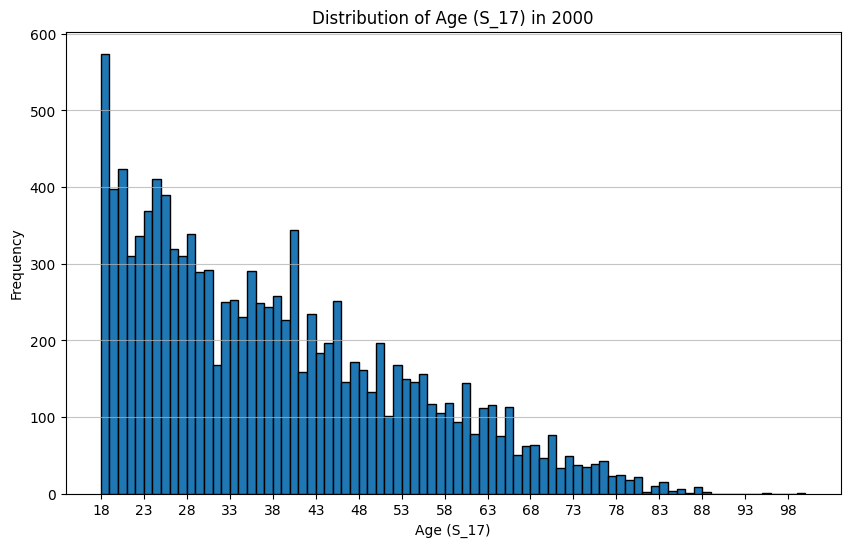

In [ ]:
# df_2013 contains data for the year 2013
plt.figure(figsize=(10, 6))
plt.hist(df_2000['S_17'], bins=range(int(df_2000['S_17'].min()), int(df_2000['S_17'].max()) + 2), edgecolor='black')
plt.title('Distribution of Age (S_17) in 2013')
plt.xlabel('Age (S_17)')
plt.ylabel('Frequency')
plt.xticks(range(int(df_2000['S_17'].min()), int(df_2000['S_17'].max()) + 1, 5)) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75)
plt.show()

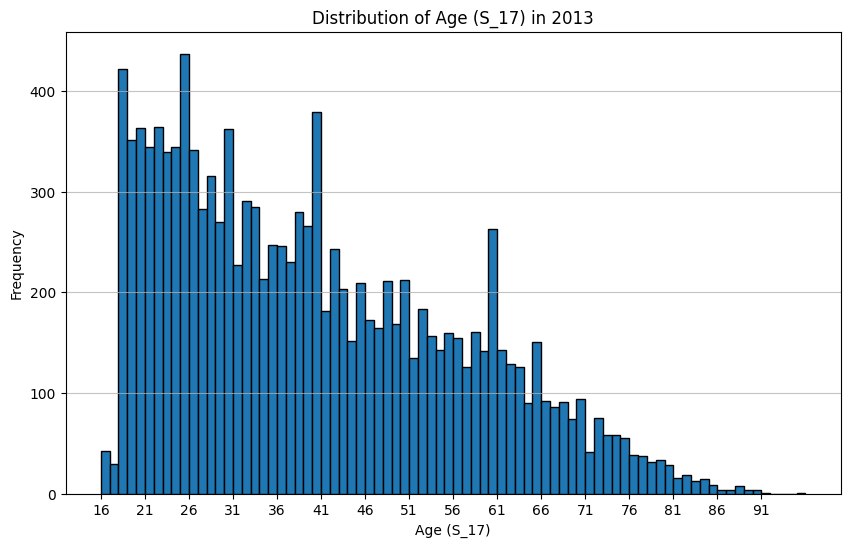

In [ ]:
# df_2013 contains data for the year 2013
plt.figure(figsize=(10, 6))
plt.hist(df_2013['S_17'], bins=range(int(df_2013['S_17'].min()), int(df_2013['S_17'].max()) + 2), edgecolor='black')
plt.title('Distribution of Age (S_17) in 2013')
plt.xlabel('Age (S_17)')
plt.ylabel('Frequency')
plt.xticks(range(int(df_2013['S_17'].min()), int(df_2013['S_17'].max()) + 1, 5)) # Adjust x-ticks for better readability
plt.grid(axis='y', alpha=0.75)
plt.show()

##